In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Project 1 ready")

Project 1 ready


In [2]:
df = pd.read_csv('housing_in_london_monthly_variables.csv')
df.head()

,date,area,average_price,code,houses_sold,no_of_crimes,borough_flag
0,1995-01-01,city of london,91449,E09000001,17.0,NaN,1
1,1995-02-01,city of london,82203,E09000001,7.0,NaN,1
2,1995-03-01,city of london,79121,E09000001,14.0,NaN,1
3,1995-04-01,city of london,77101,E09000001,7.0,NaN,1
4,1995-05-01,city of london,84409,E09000001,10.0,NaN,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13549 entries, 0 to 13548
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           13549 non-null  str    
 1   area           13549 non-null  str    
 2   average_price  13549 non-null  int64  
 3   code           13549 non-null  str    
 4   houses_sold    13455 non-null  float64
 5   no_of_crimes   7439 non-null   float64
 6   borough_flag   13549 non-null  int64  
dtypes: float64(2), int64(2), str(3)
memory usage: 741.1 KB


In [4]:
df.describe()

,average_price,houses_sold,no_of_crimes,borough_flag
count,1.354900e+04,13455.000000,7439.000000,13549.000000
mean,2.635197e+05,3893.994129,2158.352063,0.733338
std,1.876175e+05,12114.402476,902.087742,0.442230
min,4.072200e+04,2.000000,0.000000,0.000000
25%,1.323800e+05,247.000000,1623.000000,0.000000
50%,2.229190e+05,371.000000,2132.000000,1.000000
75%,3.368430e+05,3146.000000,2582.000000,1.000000
max,1.463378e+06,132163.000000,7461.000000,1.000000


In [5]:
df.isnull().sum()

date                0
area                0
average_price       0
code                0
houses_sold        94
no_of_crimes     6110
borough_flag        0
dtype: int64

In [6]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df.dtypes

date                 str
area                 str
average_price      int64
code                 str
houses_sold      float64
no_of_crimes     float64
borough_flag       int64
dtype: object

In [7]:
df['date']= pd.to_datetime(df['date'])
df.head()

,date,area,average_price,code,houses_sold,no_of_crimes,borough_flag
72,2001-01-01,city of london,284262,E09000001,24.0,0.0,1
73,2001-02-01,city of london,198137,E09000001,37.0,0.0,1
74,2001-03-01,city of london,189033,E09000001,44.0,0.0,1
75,2001-04-01,city of london,205494,E09000001,38.0,0.0,1
76,2001-05-01,city of london,223459,E09000001,30.0,0.0,1


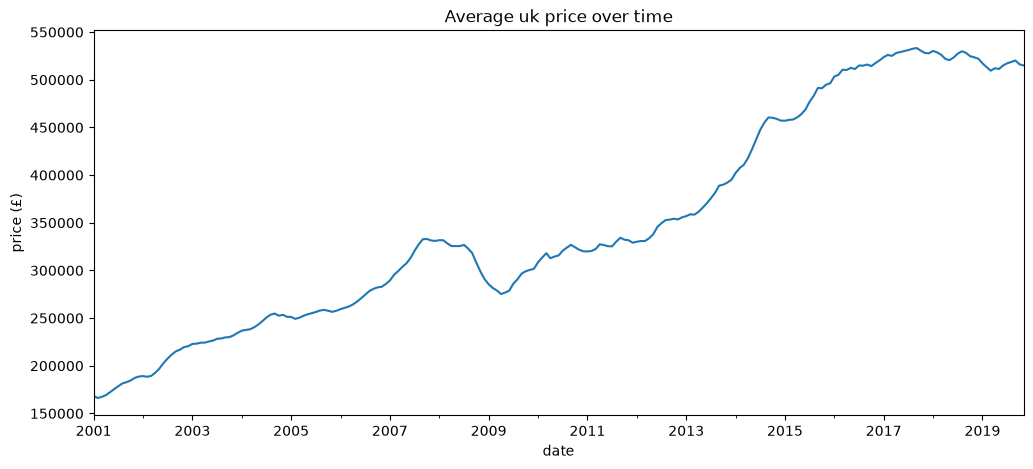

In [8]:
df.groupby('date')['average_price'].mean().plot(figsize=(12,5), title = 'Average uk price over time')
plt.xlabel('date')
plt.ylabel('price (£)')
plt.show()

In [9]:
print(df.head())
print(type(df))

         date            area  average_price       code  houses_sold  \
72 2001-01-01  city of london         284262  E09000001         24.0   
73 2001-02-01  city of london         198137  E09000001         37.0   
74 2001-03-01  city of london         189033  E09000001         44.0   
75 2001-04-01  city of london         205494  E09000001         38.0   
76 2001-05-01  city of london         223459  E09000001         30.0   

    no_of_crimes  borough_flag  
72           0.0             1  
73           0.0             1  
74           0.0             1  
75           0.0             1  
76           0.0             1  
<class 'pandas.DataFrame'>


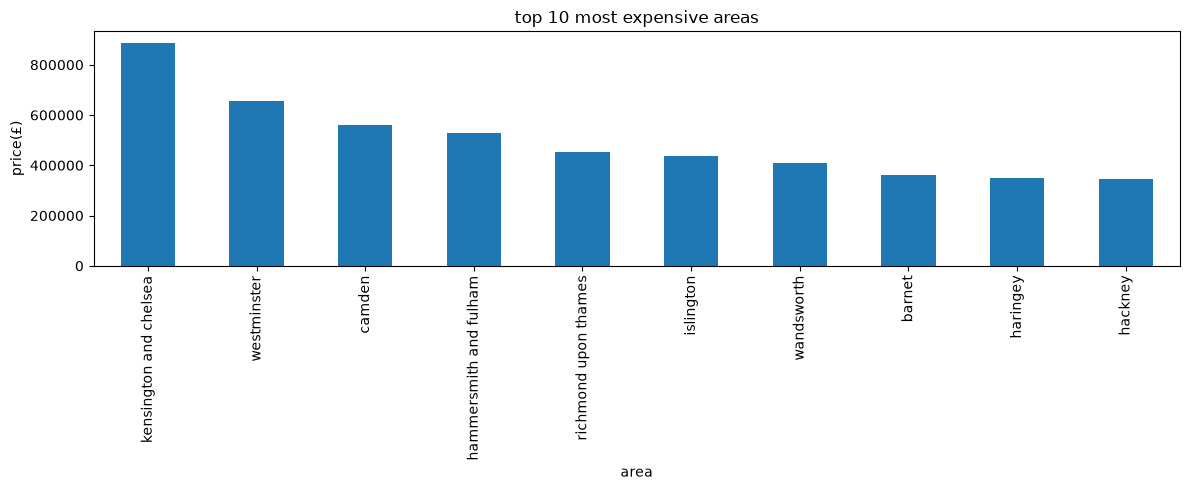

In [10]:
df.groupby('area')['average_price'].mean().sort_values(ascending=False).head(10).plot(kind='bar', figsize=(12,5), title = 'top 10 most expensive areas')
plt.ylabel('price(£)')
plt.tight_layout()
plt.show()

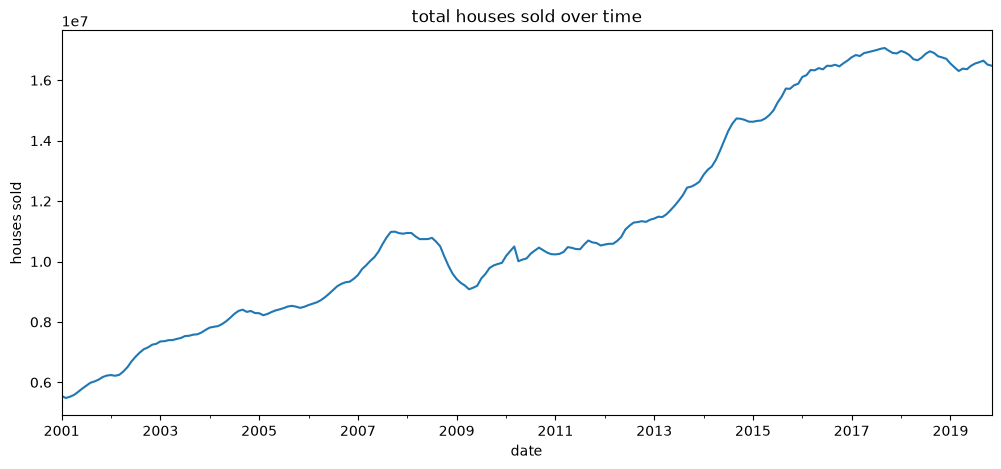

In [11]:
df.groupby('date')['average_price'].sum().plot(figsize=(12,5), title = 'total houses sold over time')
plt.ylabel('houses sold')
plt.show()

               average_price  no_of_crimes
average_price       1.000000      0.109721
no_of_crimes        0.109721      1.000000


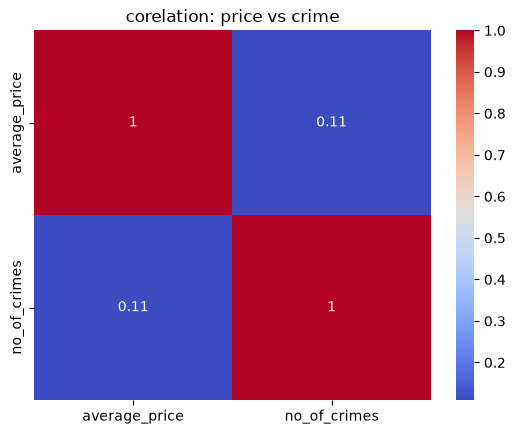

In [12]:
correlation = df[['average_price','no_of_crimes']].corr()
print(correlation)
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('corelation: price vs crime')
plt.show()

In [13]:
df.to_csv('cleaned_housing_data.csv', index=False)
print("saved")

saved


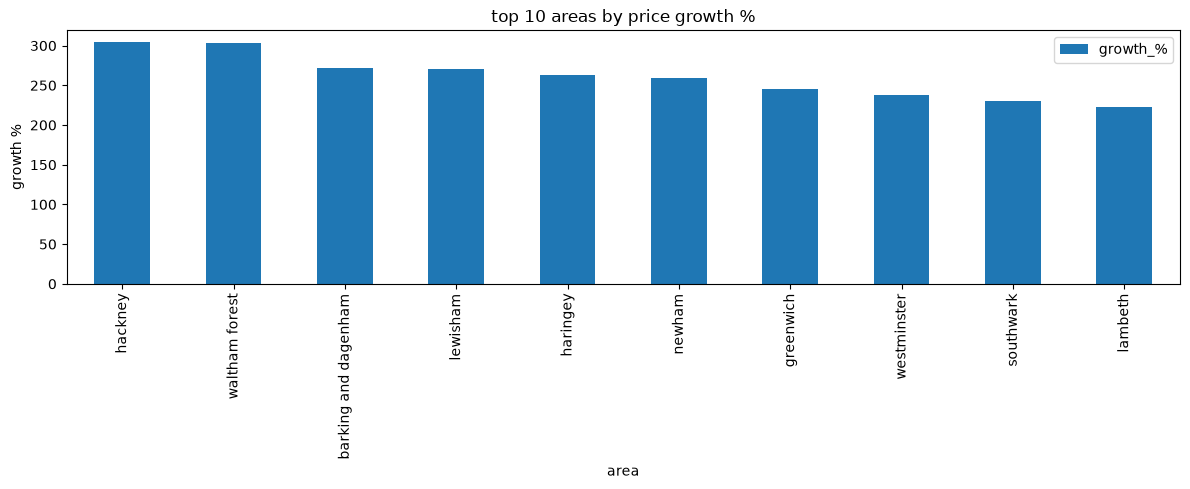

In [14]:
price_growth = df.groupby('area')['average_price'].agg(['first', 'last'])
price_growth['growth_%'] = ((price_growth['last'] - price_growth['first']) / price_growth['first']*100).round(2)
price_growth.sort_values('growth_%', ascending=False).head(10).plot(kind='bar', y='growth_%', figsize=(12,5), title='top 10 areas by price growth %')
plt.ylabel('growth %')
plt.tight_layout()
plt.show()

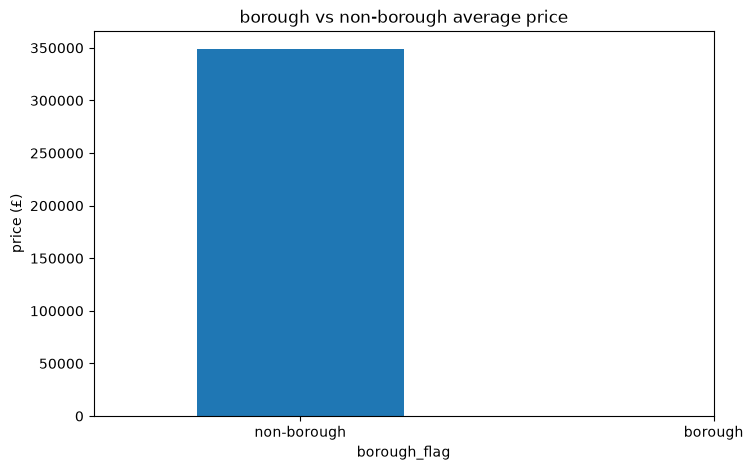

In [15]:
df.groupby('borough_flag')['average_price'].mean().plot(kind='bar', figsize=(8,5), title='borough vs non-borough average price')
plt.ylabel('price (£)')
plt.xticks([0,1], ['non-borough','borough'], rotation=0)
plt.show()

In [16]:
summary = df.groupby('area')['average_price'].agg(['mean', 'min', 'max']).round(2)
summary.columns = ['mean price', 'min price', 'max price']
print(summary.sort_values('mean price', ascending=False).head(10))


                        mean price  min price  max price
area                                                    
kensington and chelsea   888639.07     394886    1463378
westminster              654077.12     276752    1117408
camden                   559213.34     265515     881212
hammersmith and fulham   527594.00     259723     781175
richmond upon thames     451974.00     229361     682854
islington                436635.84     202308     677798
wandsworth               409200.41     192543     633826
barnet                   361831.45     175475     549401
haringey                 349932.92     154406     568649
hackney                  345281.43     139102     575846


In [17]:
import plotly
print(plotly.__version__)


6.8.0


In [21]:
import plotly.express as px

# chart 1 - Price trend over time
fig1 = px.line(df.groupby('date')['average_price'].mean().reset_index(),
               x='date', y='average_price',
               title= 'average uk house price over time',
               template='plotly_dark')
fig1.show()

# chart 2 - top 10 most expensive areas
top10 = df.groupby('area')['average_price'].mean().sort_values(ascending=False).head(10).reset_index()
fig2 = px.bar(top10, x='area', y='average_price',
              title='top 10 most expensive areas',
              template='plotly_dark',
              color='average_price',
              color_continuous_scale='Viridis')
fig2.show()

# chart 3 - houses sold over time
fig3 = px.line(df.groupby('date')['houses_sold'].sum().reset_index(),
               x='date', y='houses_sold',
               title='total houses sold over time',
               template='plotly_dark')
fig3.show()

# chart 4 - top 10 areas by price growth
price_growth = df.groupby('area')['average_price'].agg(['first','last']).reset_index()
price_growth['growth_%'] = ((price_growth['last'] - price_growth['first']) / price_growth['first'] * 100).round(2)
fig4 = px.bar(price_growth.sort_values('growth_%', ascending=False).head(10),
              x='area', y='growth_%',
              title='top 10 areas by price growth %',
              template='plotly_dark',
              color='growth_%',
              color_continuous_scale='plasma')
fig4.show()